In [173]:
import os
import json
import textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]


In [174]:
filtered_flux_results_path = '/data3/jhpark/filtered_person_1k'
filtered_flux_results_dirs = list_subdirectories(filtered_flux_results_path)
flux_results_iter = iter(filtered_flux_results_dirs)

In [175]:
def plot_explanations(parent_dir, subdirectory):
    metadata_path = os.path.join(parent_dir, subdirectory, "metadata.json")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(metadata)
    artifact_image_path = os.path.join(parent_dir, subdirectory, "artifact_image.png")
    img = mpimg.imread(artifact_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')

    for idx, artifact in enumerate(metadata['artifacts']):
        bbox = artifact['target_bbox']
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        # plt.gca().text(x1, y1 - 5, str(idx) +' ' + artifact['artifact_type'], color='white', fontsize=12, weight='bold', va='bottom', ha='left', bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1))
        if artifact['artifact_type'] == 'distortion':
            label_text = str(idx) + ' ' + artifact.get('distortion_kernel', 'distortion')
        else:
            label_text = str(idx) + ' ' + artifact['artifact_type']
        plt.gca().text(
            x1, y1 - 5, label_text,
            color='white', fontsize=12, weight='bold', va='bottom', ha='left',
            bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1)
        )
        print('\n'.join(textwrap.wrap(artifact['explanation'], width=80)))
        print('--------------------------------')
    print(metadata['caption'])
    plt.show()
        


{'artifacts': [{'target_bbox': [208, 304, 288, 368], 'artifact_type': 'addition', 'entity': 'person', 'artifact_entity': 'foot', 'explanation': 'The area shows an extra foot, making it appear as if the person has three feet, which is anatomically incorrect.', 'label': 'The person has an extra foot.'}, {'target_bbox': [112, 320, 160, 368], 'artifact_type': 'addition', 'entity': 'person', 'artifact_entity': 'hand', 'explanation': 'The hand in the area has an extra finger, making it appear as if there are six fingers instead of the usual five, which is anatomically incorrect.', 'label': 'The hand has an extra finger.'}, {'target_bbox': [320, 160, 448, 240], 'artifact_type': 'distortion', 'entity': 'person', 'artifact_entity': 'arm', 'explanation': 'The area where the arm should be is missing, creating an unnatural gap between the shoulder and the hand. This makes the arm appear incomplete and visually incorrect.', 'label': 'Missing arm section', 'distortion_kernel': 'shuffle'}], 'caption'

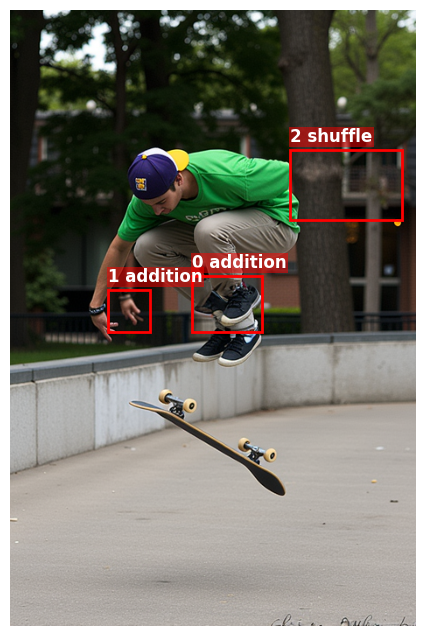

In [214]:
flux_result = next(flux_results_iter)


plot_explanations(filtered_flux_results_path, flux_result)